In [1]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
import scienceplots
from scipy.interpolate import interp1d

plt.style.use(['science', 'no-latex', 'vpedre'])

In [2]:
def aa(L, z_ini=99):
    a_ini = 1 / (1+ z_ini)
    return np.linspace(a_ini, 1, L)

def zz(L, z_ini=99):
    return np.linspace(z_ini, 0, L)

In [3]:
deltalna = 7.5e-4
lna_start = -5
lna_end = 0.25
N = int((lna_end - lna_start) / deltalna) + 1

lna_smg =   np.linspace(lna_start, lna_end, N)
DeltaM2 =   np.linspace(1e-4, 1e-4, N)
Dkin =      np.linspace(1e-4, 1e-4, N)
cs2 =       np.linspace(1., 1., N)

# Stack the arrays column-wise and save
data = np.column_stack((lna_smg, DeltaM2, Dkin, cs2))
np.savetxt("../stable_params_input/gr.dat", data, delimiter=" ")

In [4]:
pars_lcdm = {
    # MG MODEL
    # CLASS evolver
    'evolver': 0,
    'output': 'mPk,tCl',
    # 'P_k_max_1/Mpc': 3.0,
    # 'z_max_pk': 99,
    'k_output_values': '0.001'
    }

pars_w0wa_true = {
    # MG MODEL
    # Disable cosmological constant 
    'Omega_Lambda': 0,
    # Dark energy fluid parameters
    'w0_fld' : -1.3,
    'wa_fld' : 0.,
    # 'cs2_fld': 1.0,
    # CLASS evolver
    'evolver': 0,
    'output': 'mPk,tCl',
    'P_k_max_1/Mpc': 3.0,
    # 'z_max_pk': 99,
    'k_output_values': '0.001'
    }

pars_w0wa_pred = {
    # MG MODEL
    # Disable cosmological constant and DE fluid
    'Omega_Lambda': 0,
    'Omega_fld': 0,
    # Enable mochiclass
    'Omega_smg': -1,
    # Choose the model
    'root': 'output/wowa/',

    'gravity_model': 'stable_params',
    'smg_file_name' : '../stable_params_input/gr.dat', 
    # 'lna_smg': np.array2string(lna_smg, separator=',', precision=16).replace('\n','').strip('[]'),
    # 'Delta_M2': np.array2string(DeltaM2, separator=',', precision=16).replace('\n','').strip('[]'),
    # 'D_kin': np.array2string(Dkin, separator=',', precision=16).replace('\n','').strip('[]'),
    # 'cs2': np.array2string(cs2, separator=',', precision=16).replace('\n','').strip('[]'),
    'parameters_smg': '1e-5',
    'expansion_model': 'w0wa',
    'expansion_smg': '0.67, -1.3, 0.', #Lambda, w0, wa
    # CLASS evolver
    # 'evolver': 0,
    'method_qs_smg': 'automatic',
    'output': 'mPk,tCl',
    # 'P_k_max_1/Mpc': 3.0,
    # 'z_max_pk': 99,
    'k_output_values': '0.001'
}

In [5]:
def calc_cosmo(pars):
    cosmo = Class()
    cosmo.set(pars)
    cosmo.compute()

    # Get the perturbations
    bk =  cosmo.get_background()
    pt = cosmo.get_perturbations()
    
    cosmo.struct_cleanup()
    cosmo.empty()
    return bk, pt

In [6]:
lcdm = calc_cosmo(pars_lcdm)
w0wa_true = calc_cosmo(pars_w0wa_true)
w0wa_pred = calc_cosmo(pars_w0wa_pred)

In [7]:
lcdm_a = 1/(1+lcdm[0]['z'])
w0wa_true_a = 1/(1+w0wa_true[0]['z'])
w0wa_pred_a = 1/(1+w0wa_pred[0]['z'])

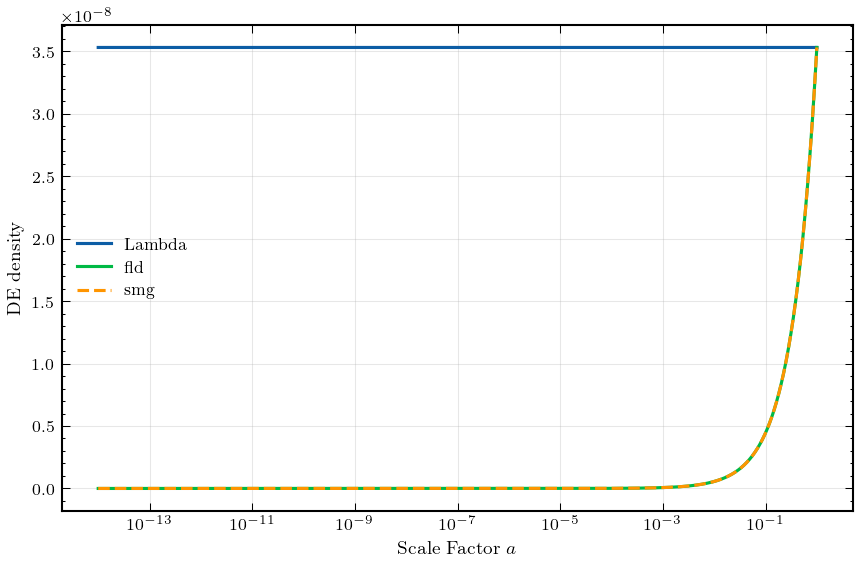

In [8]:
fig, ax = plt.subplots()

ax.semilogx(lcdm_a      , lcdm[0]['(.)rho_lambda'], label='Lambda')
ax.semilogx(w0wa_true_a , w0wa_true[0]['(.)rho_fld'], label='fld')
ax.semilogx(w0wa_pred_a , w0wa_pred[0]['(.)rho_smg'], '--', label='smg')

# ax.invert_xaxis()
ax.set_ylabel('DE density')
ax.set_xlabel('Scale Factor $a$')
ax.legend()


In [9]:
def interp(x_array,f_array):
    # Create interpolating function (linear or cubic)
    f_interp = interp1d(x_array, f_array, kind='linear', fill_value="extrapolate")
    
    return f_interp


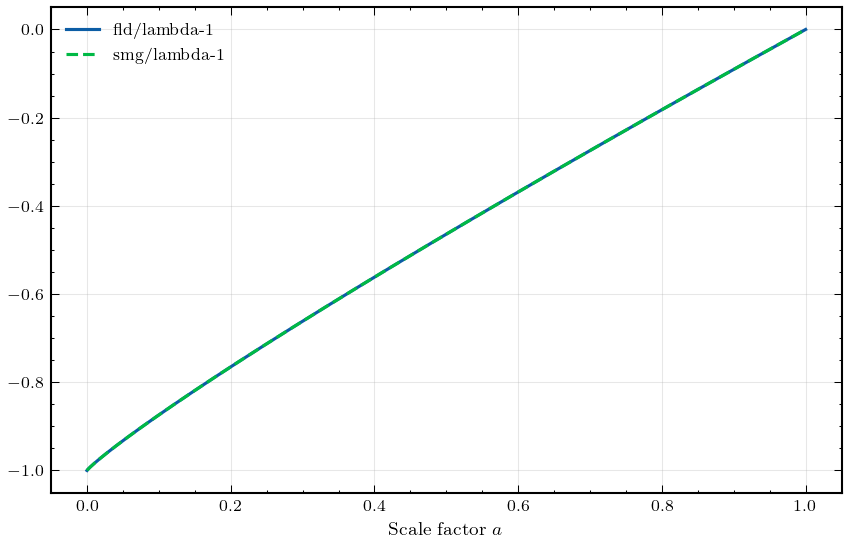

In [10]:
fig, ax = plt.subplots()

ax.plot(lcdm_a, w0wa_true[0]['(.)rho_fld']/lcdm[0]['(.)rho_lambda']-1, label=r'fld/lambda-1')
ax.plot(lcdm_a, interp(w0wa_pred_a, w0wa_pred[0]['(.)rho_smg'])(lcdm_a)/lcdm[0]['(.)rho_lambda']-1, '--', label=r'smg/lambda-1')

# ax.set_ylabel(r'$\frac{\rho_\text{de}}{\rho_\Lambda}-1$')
ax.set_xlabel('Scale factor $a$')
ax.legend()


In [11]:
print(lcdm[1]['scalar'][0].keys(),'\n',w0wa_true[1]['scalar'][0].keys(),'\n',w0wa_pred[1]['scalar'][0].keys())

dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'theta_tot', 'h_prime', 'h_prime_prime', 'eta', 'eta_prime', 'alpha', 'alpha_prime', 'einstein00', 'H_T_prime']) 
 dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_rho_fld', 'rho_plus_p_theta_fld', 'delta_p_fld', 'delta_fld', 'theta_fld', 'cs2_fld', 'theta_tot', 'h_prime', 'h_prime_prime', 'eta', 'eta_prime', 'alpha', 'alpha_prime', 'einstein00', 'H_T_prime']) 
 dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'theta_tot', 'V_x_smg', 'V_x_prime_smg', 'V_x_prime_prime_smg', 'mass2_qs', 'mass2_qs_p', 'rad2_qs', 'frict

In [12]:
lcdm[1]['scalar'][0]['a']

array([4.54843159e-04, 6.93448850e-04, 6.94003611e-04, 6.94560620e-04,
       6.95119906e-04, 6.95681500e-04, 6.96245430e-04, 6.96811728e-04,
       6.97380425e-04, 6.97951553e-04, 6.98525142e-04, 6.99101225e-04,
       6.99679836e-04, 7.00261008e-04, 7.00844774e-04, 7.01431170e-04,
       7.02020231e-04, 7.02611992e-04, 7.03206491e-04, 7.03803763e-04,
       7.04403848e-04, 7.05006784e-04, 7.05612610e-04, 7.06221365e-04,
       7.06833091e-04, 7.07447829e-04, 7.08065622e-04, 7.08686511e-04,
       7.09310541e-04, 7.09937757e-04, 7.10568204e-04, 7.11201928e-04,
       7.11838977e-04, 7.12479398e-04, 7.13123241e-04, 7.13770557e-04,
       7.14421394e-04, 7.15075807e-04, 7.15733848e-04, 7.16395571e-04,
       7.17061031e-04, 7.17730284e-04, 7.18403389e-04, 7.19080404e-04,
       7.19761388e-04, 7.20446403e-04, 7.21135512e-04, 7.21828778e-04,
       7.22526266e-04, 7.23228043e-04, 7.23934177e-04, 7.24644740e-04,
       7.25359803e-04, 7.26079439e-04, 7.26803724e-04, 7.27532735e-04,
      

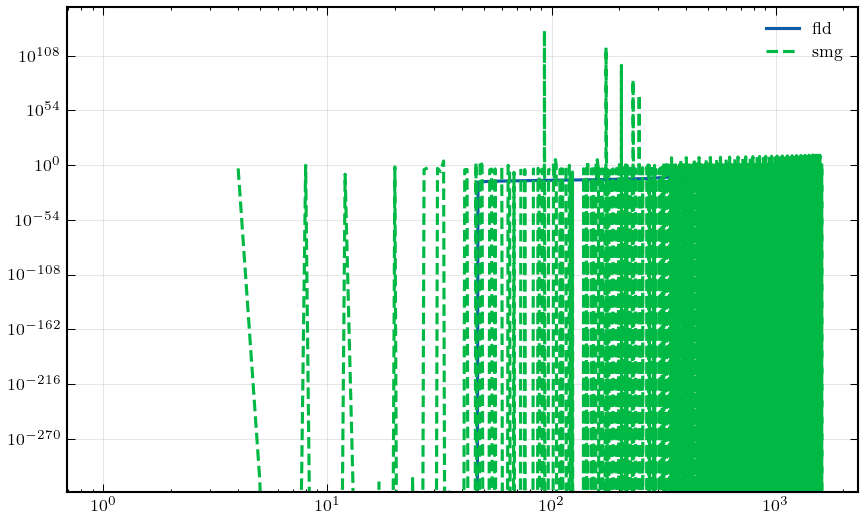

In [13]:
fig, ax = plt.subplots()

ax.loglog(w0wa_true[1]['scalar'][0]['delta_rho_fld'], label='fld')
ax.loglog(w0wa_pred[1]['scalar'][0]['V_x_smg'], '--', label= 'smg')

ax.legend()

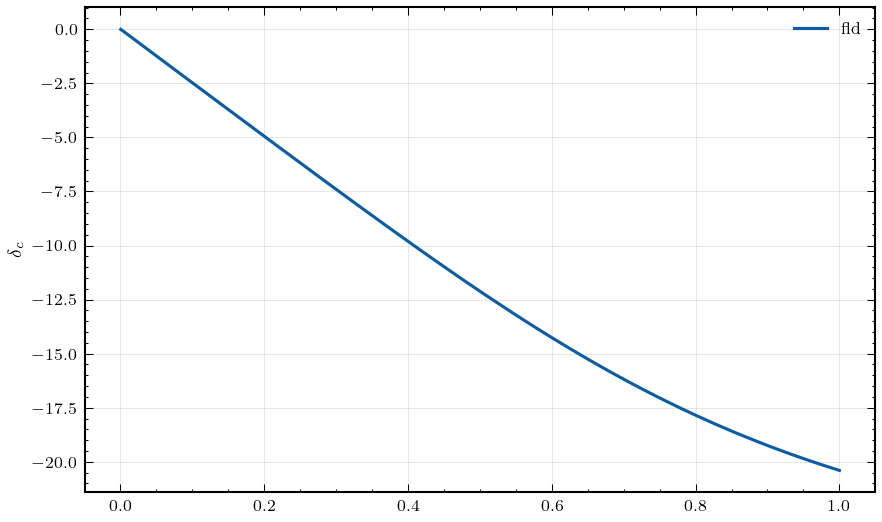

In [14]:
fig, ax = plt.subplots()

# ax.plot(lcdm[1]['scalar'][0]['delta_cdm'])
# ax.plot(lcdm[1]['scalar'][0]['delta_cdm'], label='lcdm')
ax.plot(w0wa_true[1]['scalar'][0]['a'], w0wa_true[1]['scalar'][0]['delta_cdm'], label='fld')
# ax.plot(w0wa_pred[1]['scalar'][0]['delta_cdm'], label='smg')

ax.set_ylabel('$\delta_{c}$')

ax.legend()

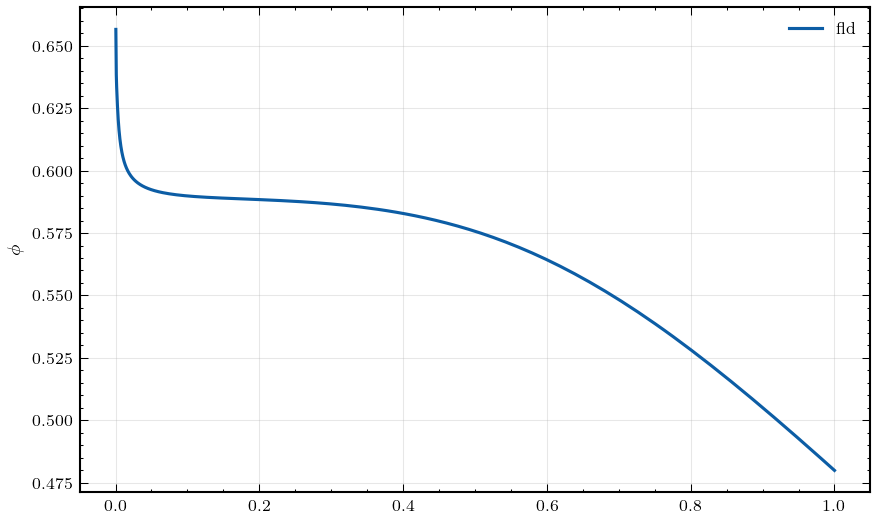

In [15]:
fig, ax = plt.subplots()

# ax.plot(lcdm[1]['scalar'][0]['delta_cdm'])
# ax.plot(aa(len(lcdm[1]['scalar'][0]['tau [Mpc]'])), lcdm[1]['scalar'][0]['phi'], label='lcdm')
ax.plot(w0wa_true[1]['scalar'][0]['a'], w0wa_true[1]['scalar'][0]['phi'], label='fld')
# ax.plot(w0wa_pred[1]['scalar'][0]['phi'], label='smg')

ax.set_ylabel('$\phi$')
ax.legend()